In [1]:
# Cell 1: Imports and load datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

train = pd.read_csv("/content/train.csv")
features = pd.read_csv("/content/features.csv")
stores = pd.read_csv("/content/stores.csv")
test = pd.read_csv("/content/test.csv")

print("train shape   :", train.shape)
print("features shape:", features.shape)
print("stores shape  :", stores.shape)
print("test shape    :", test.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nFeatures columns:")
print(features.columns.tolist())

print("\nStores columns:")
print(stores.columns.tolist())

train shape   : (421570, 5)
features shape: (8190, 12)
stores shape  : (45, 3)
test shape    : (115064, 4)

Train columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

Features columns:
['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

Stores columns:
['Store', 'Type', 'Size']


In [2]:
# Cell 2: Parse dates, merge datasets, and basic NA check

# Parse Date columns
for df in (train, test, features):
    df["Date"] = pd.to_datetime(df["Date"])

# Sort train and test for sanity
train = train.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
test = test.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

# Merge train with features on Store + Date
train_merged = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left",
    validate="many_to_one"  # each (Store, Date, IsHoliday) in features should be unique
)

# Merge store metadata
train_merged = train_merged.merge(
    stores,
    on="Store",
    how="left",
    validate="many_to_one"
)

print("train_merged shape:", train_merged.shape)
print("\ntrain_merged columns:")
print(train_merged.columns.tolist())

print("\nMissing values (top 15 columns by NA count):")
print(
    train_merged.isna()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print("\nTrain_merged date range:", train_merged["Date"].min(), "to", train_merged["Date"].max())
print("Unique stores:", train_merged["Store"].nunique())
print("Unique depts :", train_merged["Dept"].nunique())

train_merged shape: (421570, 16)

train_merged columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']

Missing values (top 15 columns by NA count):
MarkDown2       310322
MarkDown4       286603
MarkDown3       284479
MarkDown1       270889
MarkDown5       270138
Store                0
Date                 0
Dept                 0
Fuel_Price           0
Temperature          0
IsHoliday            0
Weekly_Sales         0
CPI                  0
Unemployment         0
Type                 0
dtype: int64

Train_merged date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Unique stores: 45
Unique depts : 81


Overall series length: 143
Overall date range  : 2010-02-05 00:00:00 to 2012-10-26 00:00:00

First 5 rows:
Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
Name: Weekly_Sales, dtype: float64


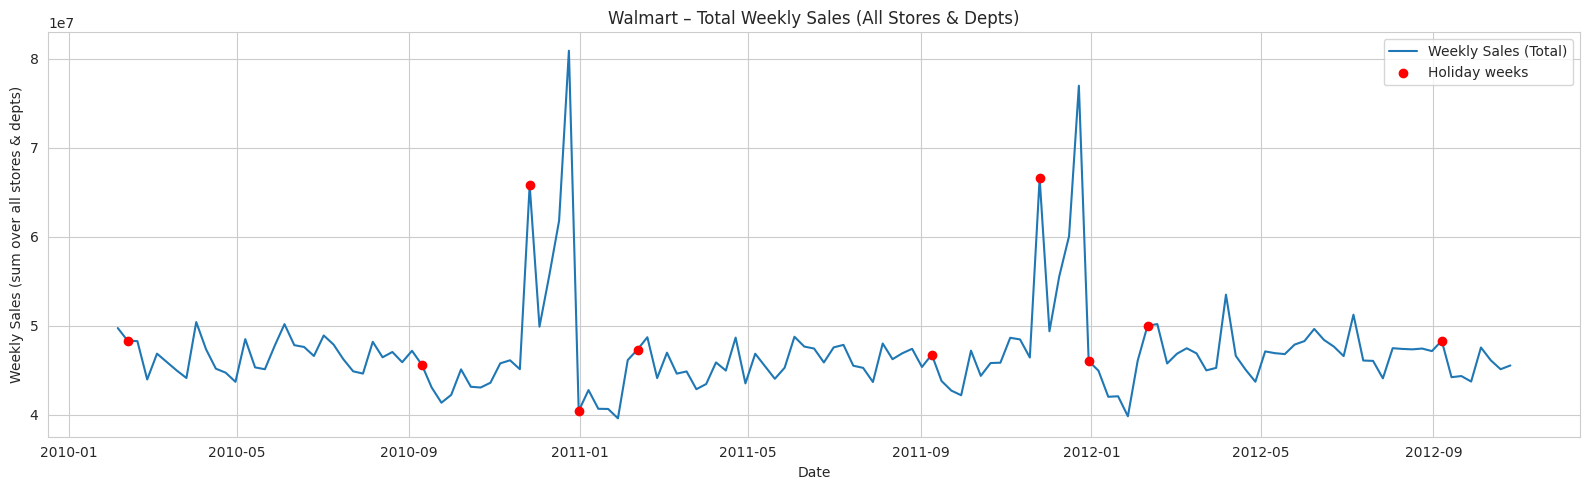

In [3]:
# Cell 3: Overall weekly sales time series (all stores + depts)

# Aggregate over Store & Dept per Date
overall_ts = (
    train_merged
    .groupby("Date", as_index=True)["Weekly_Sales"]
    .sum()
    .sort_index()
)

print("Overall series length:", len(overall_ts))
print("Overall date range  :", overall_ts.index.min(), "to", overall_ts.index.max())
print("\nFirst 5 rows:")
print(overall_ts.head())

# Identify holiday vs non-holiday total sales
holiday_flags = (
    train_merged
    .groupby("Date", as_index=True)["IsHoliday"]
    .max()          # if any store is holiday, treat that date as holiday
    .reindex(overall_ts.index)
)

# Plot overall weekly sales with holiday markers
plt.figure(figsize=(16, 5))
plt.plot(overall_ts.index, overall_ts.values, label="Weekly Sales (Total)", color="C0")

# Highlight holiday weeks
holiday_dates = overall_ts.index[holiday_flags.astype(bool)]
holiday_sales = overall_ts.loc[holiday_dates]

plt.scatter(holiday_dates, holiday_sales, color="red", label="Holiday weeks", zorder=3)

plt.title("Walmart – Total Weekly Sales (All Stores & Depts)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales (sum over all stores & depts)")
plt.legend()
plt.tight_layout()
plt.show()

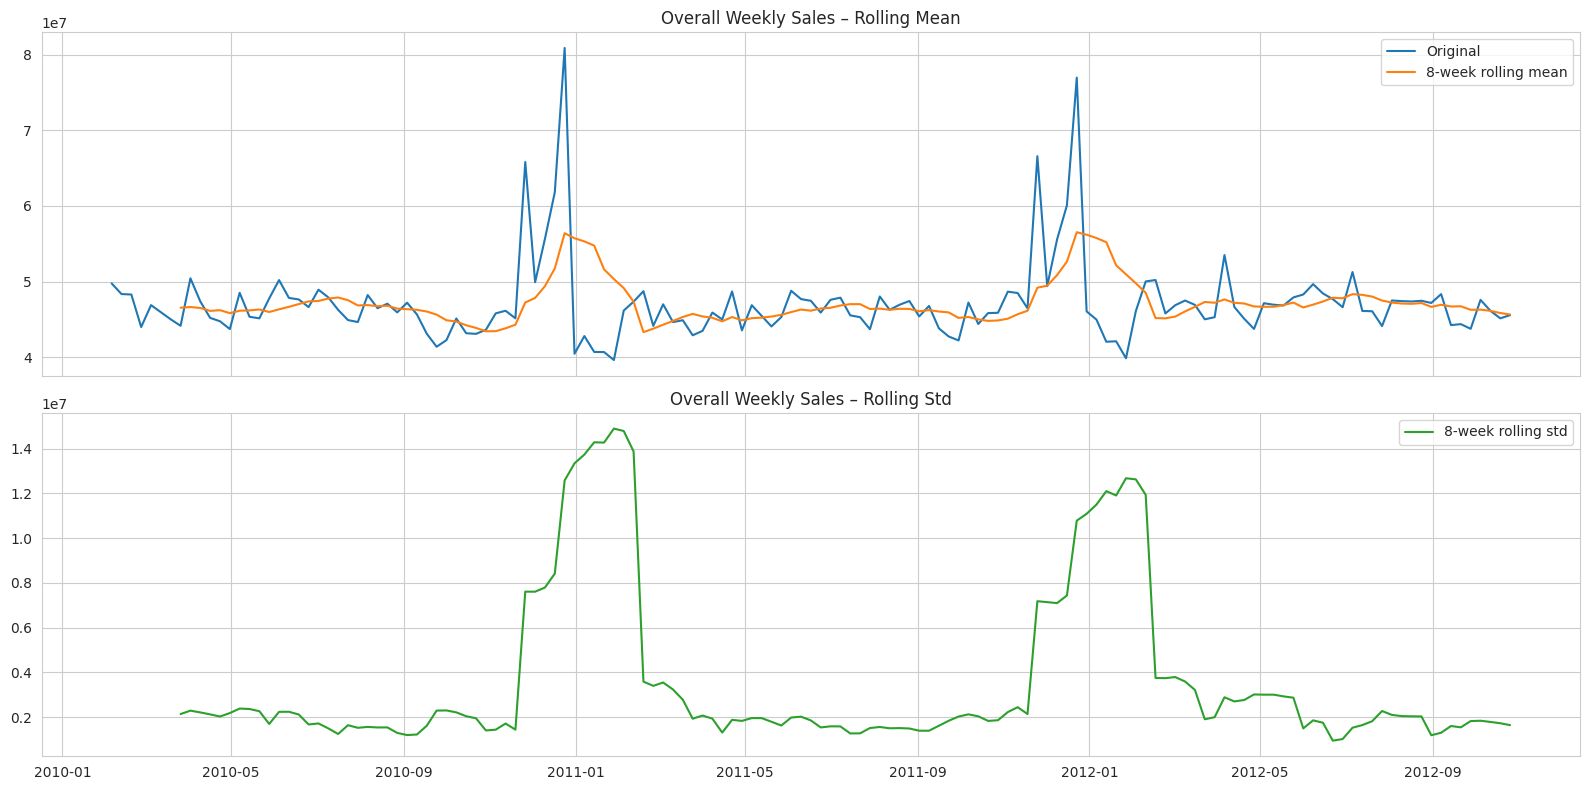

ADF test on original series
ADF statistic: -5.9083
p-value      : 0.0000
Critical values:
  1%: -3.4786
  5%: -2.8827
  10%: -2.5781

ADF test on 1st-differenced series
ADF statistic: -6.6995
p-value      : 0.0000
Critical values:
  1%: -3.4801
  5%: -2.8834
  10%: -2.5784


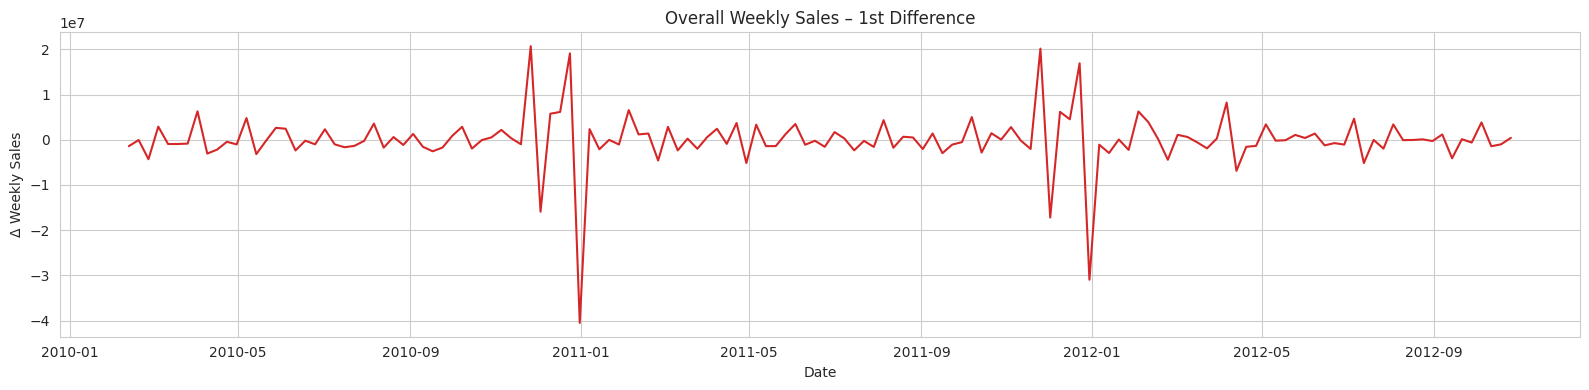

In [4]:
# Cell 4: Rolling statistics, ADF test, and differencing

from statsmodels.tsa.stattools import adfuller

# Compute rolling mean and std with 8-week window
window = 8
rolling_mean = overall_ts.rolling(window=window, center=False).mean()
rolling_std = overall_ts.rolling(window=window, center=False).std()

fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax[0].plot(overall_ts.index, overall_ts.values, label="Original", color="C0")
ax[0].plot(rolling_mean.index, rolling_mean.values, label=f"{window}-week rolling mean", color="C1")
ax[0].set_title("Overall Weekly Sales – Rolling Mean")
ax[0].legend()

ax[1].plot(rolling_std.index, rolling_std.values, label=f"{window}-week rolling std", color="C2")
ax[1].set_title("Overall Weekly Sales – Rolling Std")
ax[1].legend()

plt.tight_layout()
plt.show()

# Augmented Dickey–Fuller test on original series
adf_result = adfuller(overall_ts.values)

print("ADF test on original series")
print(f"ADF statistic: {adf_result[0]:.4f}")
print(f"p-value      : {adf_result[1]:.4f}")
print("Critical values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

# First difference
overall_diff1 = overall_ts.diff().dropna()

# ADF on differenced series
adf_diff1 = adfuller(overall_diff1.values)
print("\nADF test on 1st-differenced series")
print(f"ADF statistic: {adf_diff1[0]:.4f}")
print(f"p-value      : {adf_diff1[1]:.4f}")
print("Critical values:")
for key, value in adf_diff1[4].items():
    print(f"  {key}: {value:.4f}")

# Plot differenced series
plt.figure(figsize=(16, 4))
plt.plot(overall_diff1.index, overall_diff1.values, color="C3")
plt.title("Overall Weekly Sales – 1st Difference")
plt.xlabel("Date")
plt.ylabel("Δ Weekly Sales")
plt.tight_layout()
plt.show()

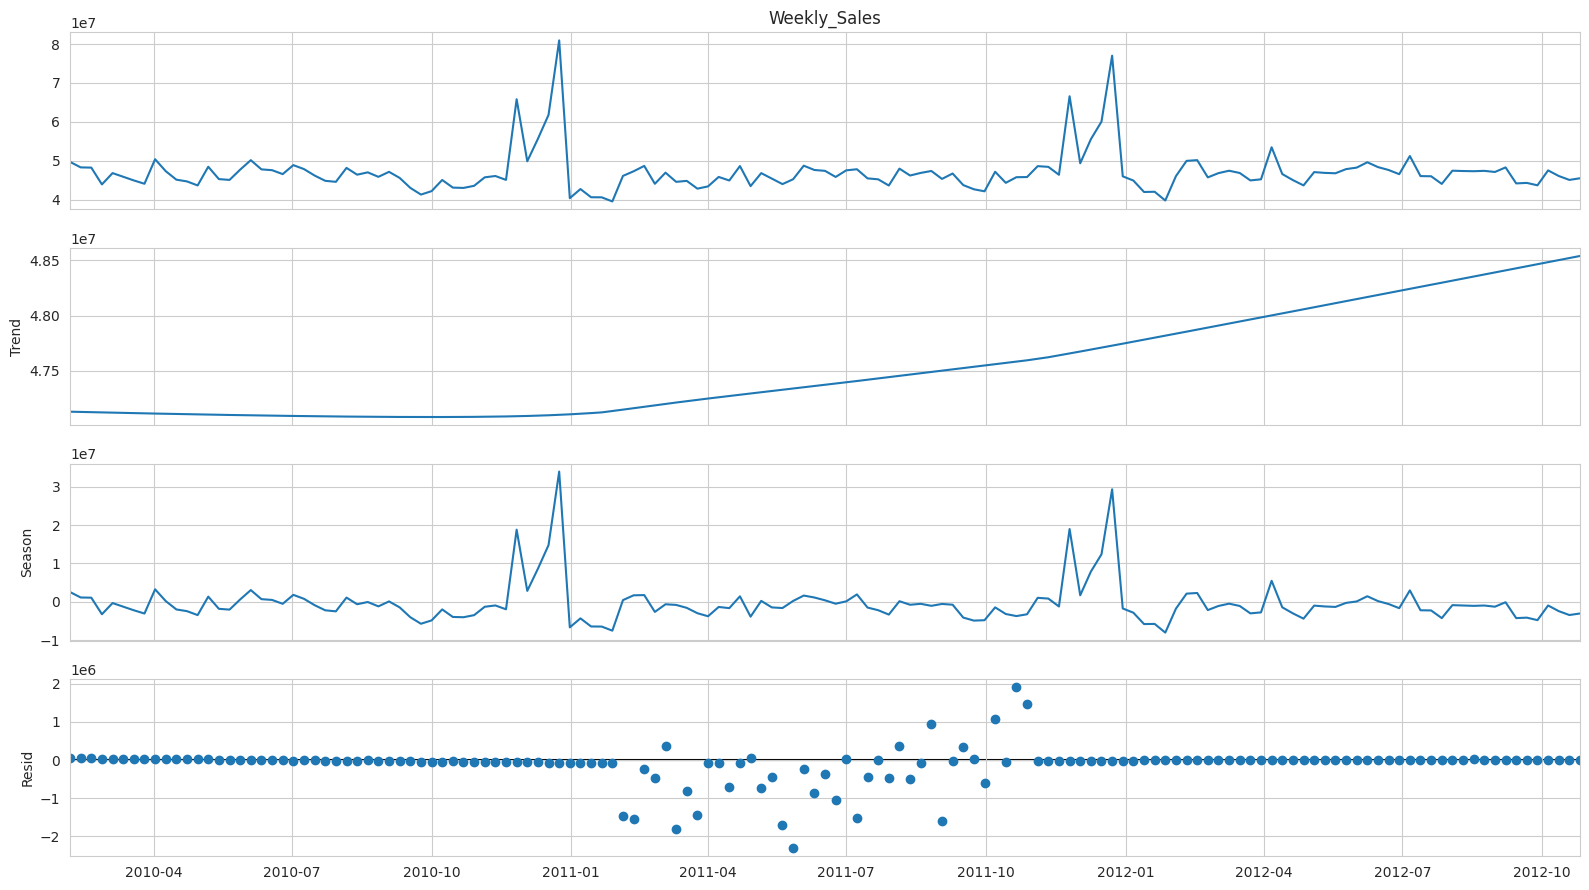

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  143
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 52)   Log Likelihood               -1470.357
Date:                            Tue, 12 May 2026   AIC                           2950.713
Time:                                    08:03:39   BIC                           2963.156
Sample:                                02-05-2010   HQIC                          2955.729
                                     - 10-26-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9846      0.138      7.153      0.000       0.715       1.254
ma.L1         -0.3643      0.499   

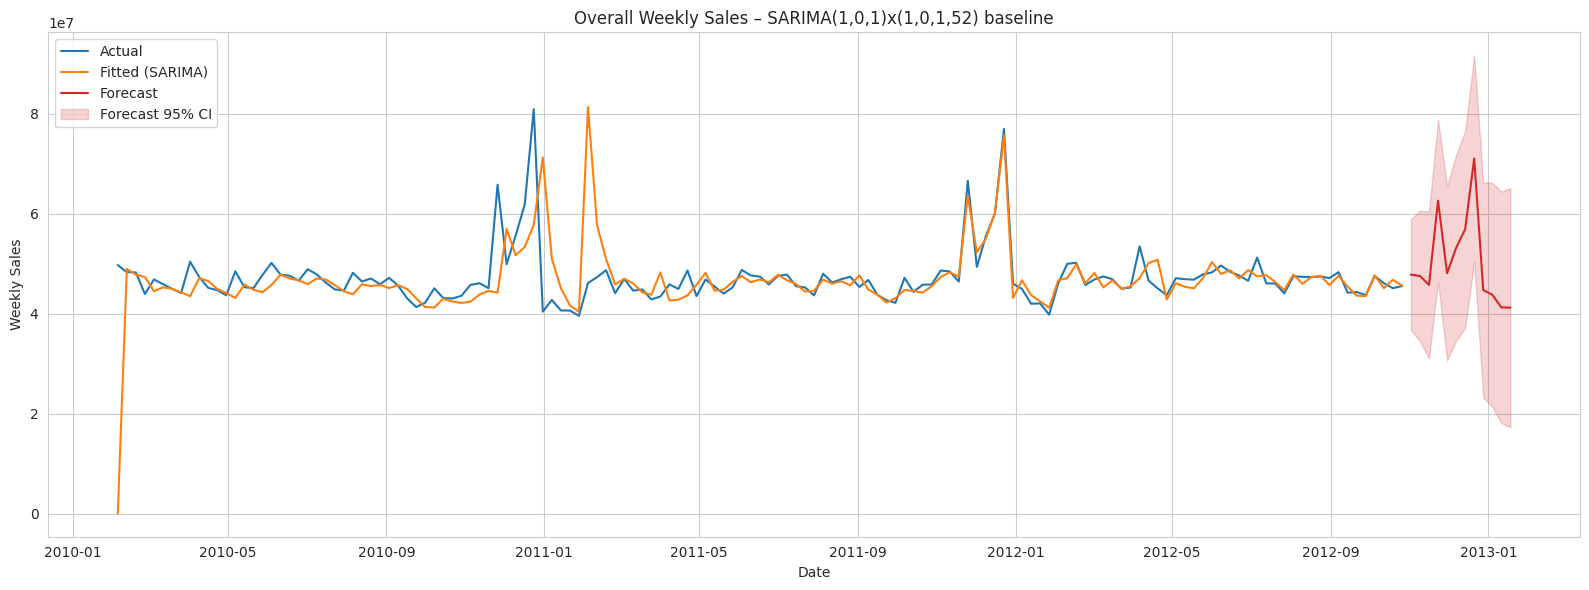

In [5]:
# Cell 5: STL decomposition and simple SARIMA baseline on overall series

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure Date index
overall_ts = overall_ts.asfreq("W-FRI")  # dataset is weekly; align to Fridays

# STL decomposition with yearly-ish seasonality (52 weeks)
stl = STL(overall_ts, period=52, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(16, 9)
fig.tight_layout()
plt.show()

# Simple SARIMA model
# We'll use a small order to keep it fast: (p,d,q) = (1,0,1), seasonal (1,0,1,52)
sarima_model = SARIMAX(
    overall_ts,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_res = sarima_model.fit(disp=False)

print(sarima_res.summary())

# In-sample fitted vs actual + 12-week ahead forecast
n_forecast = 12
pred = sarima_res.get_prediction()
pred_mean = pred.predicted_mean

forecast = sarima_res.get_forecast(steps=n_forecast)
forecast_idx = forecast.row_labels
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

plt.figure(figsize=(16, 6))
plt.plot(overall_ts.index, overall_ts.values, label="Actual", color="C0")
plt.plot(pred_mean.index, pred_mean.values, label="Fitted (SARIMA)", color="C1")

plt.plot(forecast_idx, forecast_mean, label="Forecast", color="C3")
plt.fill_between(
    forecast_idx,
    forecast_ci["lower Weekly_Sales"],
    forecast_ci["upper Weekly_Sales"],
    color="C3",
    alpha=0.2,
    label="Forecast 95% CI",
)

plt.title("Overall Weekly Sales – SARIMA(1,0,1)x(1,0,1,52) baseline")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()

Store 1 series length: 143
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00

First 5 rows:
Date
2010-02-05    1643690.90
2010-02-12    1641957.44
2010-02-19    1611968.17
2010-02-26    1409727.59
2010-03-05    1554806.68
Name: Weekly_Sales, dtype: float64


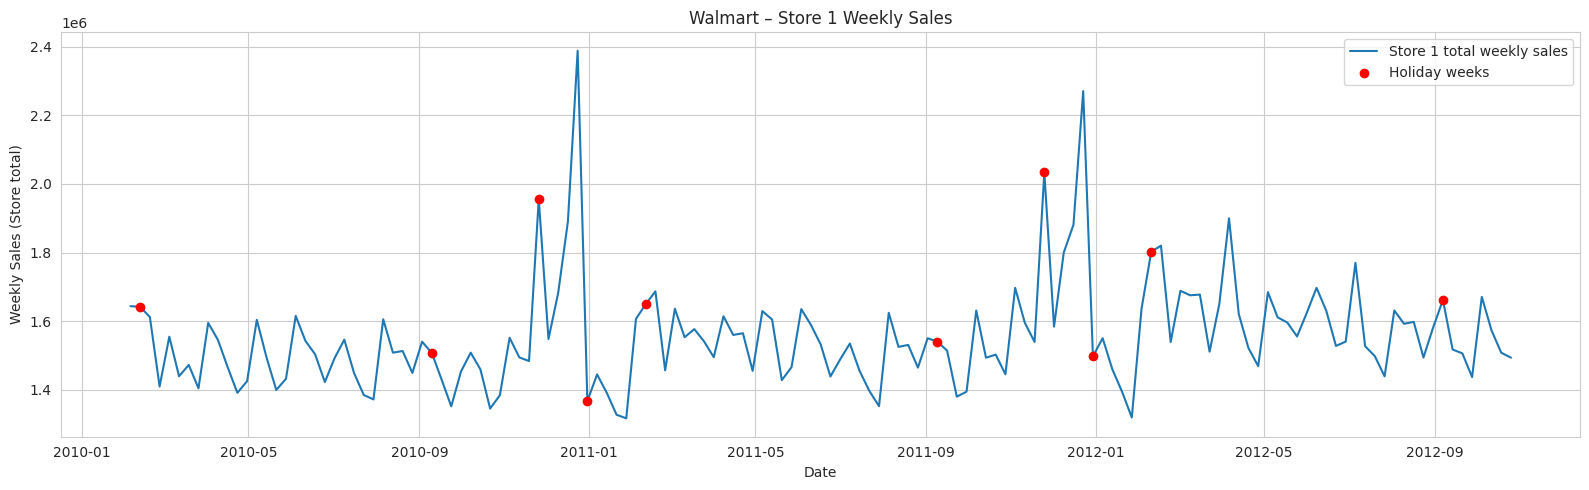

In [6]:
# Cell 6: Store-level time series example (Store 1 total sales)

store_id = 1  # you can change this later if you want

store1_ts = (
    train_merged[train_merged["Store"] == store_id]
    .groupby("Date", as_index=True)["Weekly_Sales"]
    .sum()
    .sort_index()
)

print(f"Store {store_id} series length:", len(store1_ts))
print("Date range:", store1_ts.index.min(), "to", store1_ts.index.max())
print("\nFirst 5 rows:")
print(store1_ts.head())

# Holiday flags for this store
store1_holiday = (
    train_merged[train_merged["Store"] == store_id]
    .groupby("Date", as_index=True)["IsHoliday"]
    .max()
    .reindex(store1_ts.index)
)

plt.figure(figsize=(16, 5))
plt.plot(store1_ts.index, store1_ts.values, label=f"Store {store_id} total weekly sales", color="C0")

holiday_dates_s1 = store1_ts.index[store1_holiday.astype(bool)]
holiday_sales_s1 = store1_ts.loc[holiday_dates_s1]
plt.scatter(holiday_dates_s1, holiday_sales_s1, color="red", label="Holiday weeks", zorder=3)

plt.title(f"Walmart – Store {store_id} Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales (Store total)")
plt.legend()
plt.tight_layout()
plt.show()

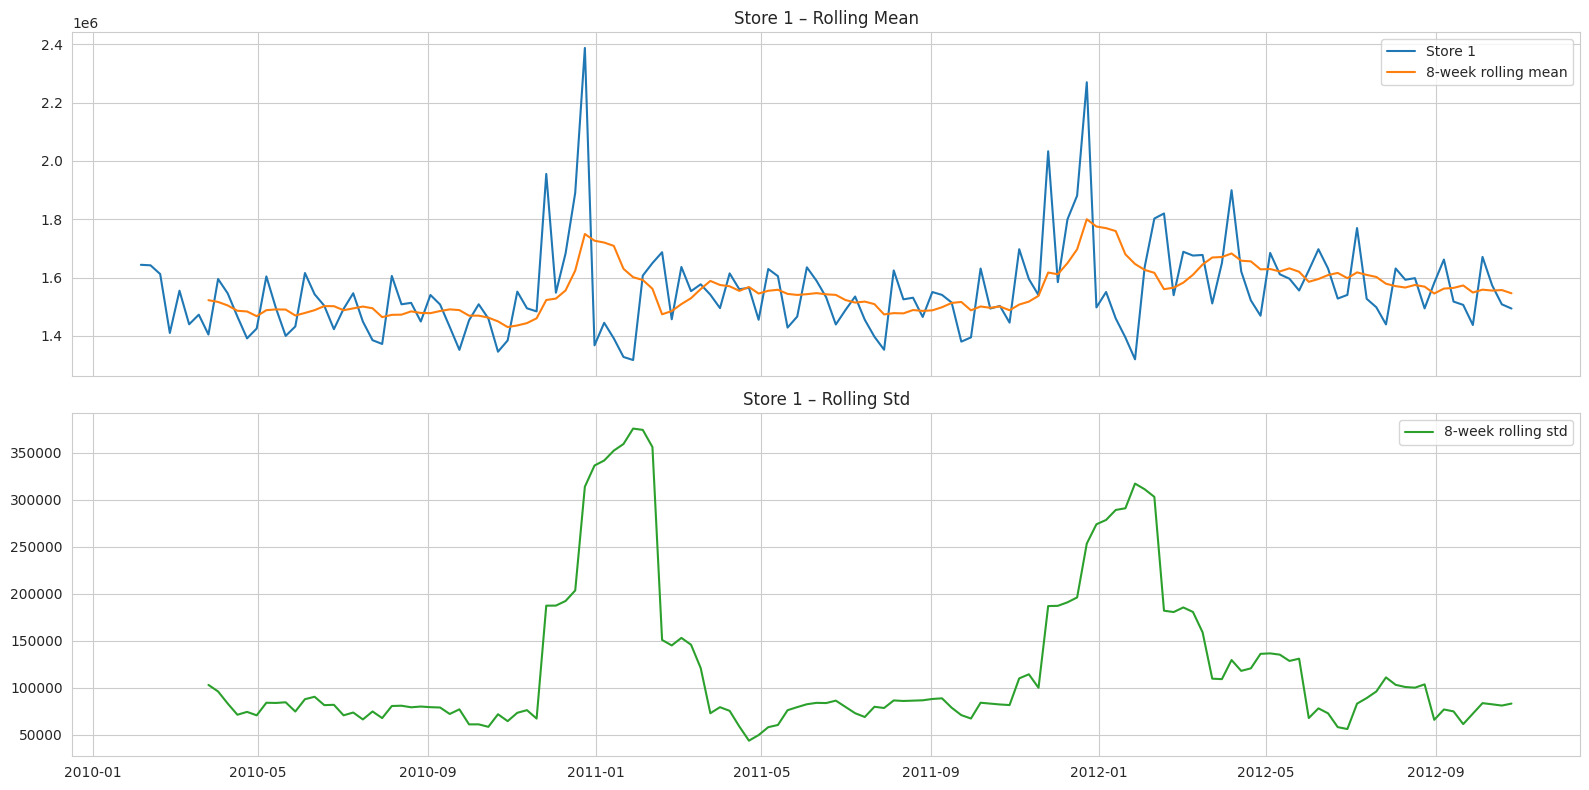

Store 1 – ADF on original
ADF statistic: -5.1022
p-value      :  0.0000
Critical values:
  1%: -3.4786
  5%: -2.8827
  10%: -2.5781

Store 1 – ADF on 1st difference
ADF statistic: -7.2616
p-value      :  0.0000
Critical values:
  1%: -3.4801
  5%: -2.8834
  10%: -2.5784


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



Store 1 – SARIMA(1,0,1)x(1,0,1,52) summary:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9760      0.101      9.637      0.000       0.778       1.175
ma.L1         -0.4144      0.230     -1.802      0.072      -0.865       0.036
ar.S.L52       0.9079      0.307      2.954      0.003       0.306       1.510
ma.S.L52      -0.0751      0.241     -0.311      0.755      -0.547       0.397
sigma2      2.768e+10   1.06e-12   2.61e+22      0.000    2.77e+10    2.77e+10


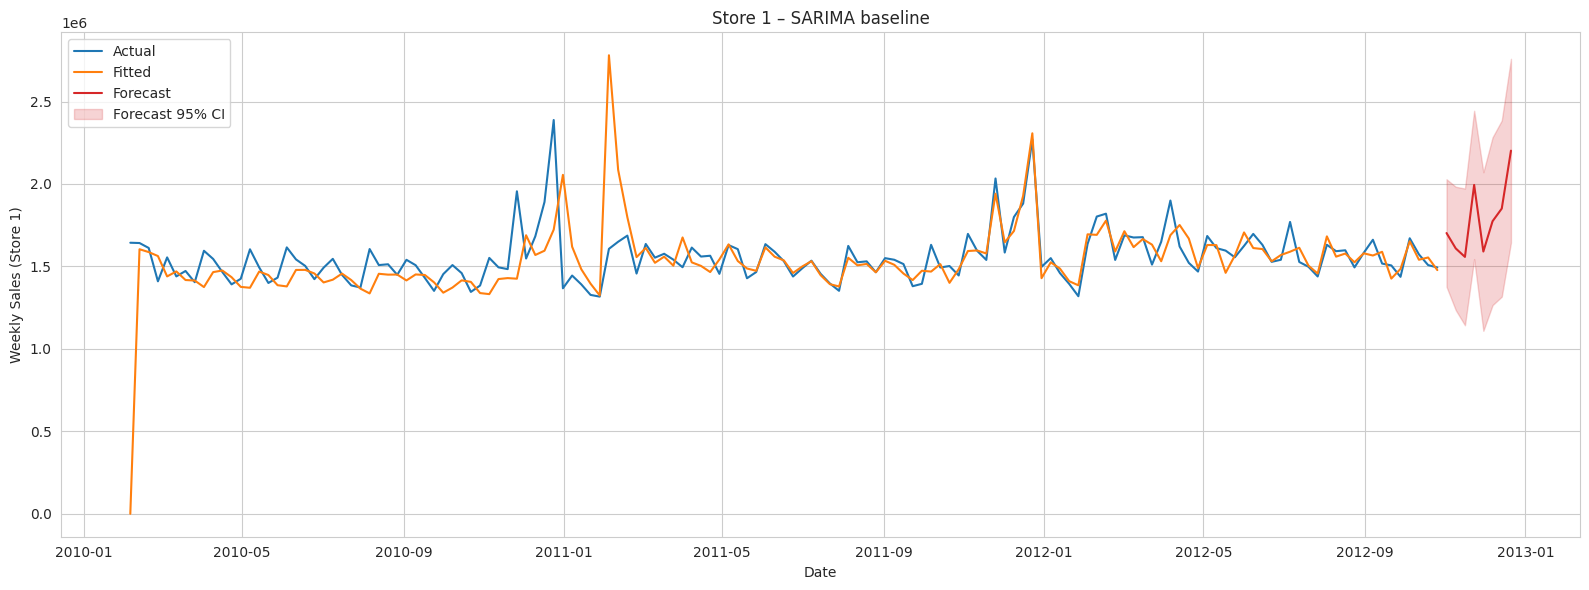

In [7]:
# Cell 7: Store 1 – rolling stats, ADF, and simple SARIMA

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure weekly frequency
store1_ts = store1_ts.asfreq("W-FRI")

# Rolling stats
window = 8
s1_roll_mean = store1_ts.rolling(window=window).mean()
s1_roll_std = store1_ts.rolling(window=window).std()

fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax[0].plot(store1_ts.index, store1_ts.values, label="Store 1", color="C0")
ax[0].plot(s1_roll_mean.index, s1_roll_mean.values,
           label=f"{window}-week rolling mean", color="C1")
ax[0].set_title("Store 1 – Rolling Mean")
ax[0].legend()

ax[1].plot(s1_roll_std.index, s1_roll_std.values,
           label=f"{window}-week rolling std", color="C2")
ax[1].set_title("Store 1 – Rolling Std")
ax[1].legend()

plt.tight_layout()
plt.show()

# ADF tests
adf_s1 = adfuller(store1_ts.dropna().values)
print("Store 1 – ADF on original")
print(f"ADF statistic: {adf_s1[0]: .4f}")
print(f"p-value      : {adf_s1[1]: .4f}")
print("Critical values:")
for k, v in adf_s1[4].items():
    print(f"  {k}: {v:.4f}")

s1_diff1 = store1_ts.diff().dropna()
adf_s1_diff = adfuller(s1_diff1.values)
print("\nStore 1 – ADF on 1st difference")
print(f"ADF statistic: {adf_s1_diff[0]: .4f}")
print(f"p-value      : {adf_s1_diff[1]: .4f}")
print("Critical values:")
for k, v in adf_s1_diff[4].items():
    print(f"  {k}: {v:.4f}")

# Simple SARIMA baseline for Store 1
s1_model = SARIMAX(
    store1_ts,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
s1_res = s1_model.fit(disp=False)

print("\nStore 1 – SARIMA(1,0,1)x(1,0,1,52) summary:")
print(s1_res.summary().tables[1])  # only coef table to keep output short

# In-sample fitted + 8-week forecast
n_forecast = 8
s1_pred = s1_res.get_prediction()
s1_pred_mean = s1_pred.predicted_mean

s1_forecast = s1_res.get_forecast(steps=n_forecast)
s1_fc_idx = s1_forecast.row_labels
s1_fc_mean = s1_forecast.predicted_mean
s1_fc_ci = s1_forecast.conf_int()

plt.figure(figsize=(16, 6))
plt.plot(store1_ts.index, store1_ts.values, label="Actual", color="C0")
plt.plot(s1_pred_mean.index, s1_pred_mean.values, label="Fitted", color="C1")
plt.plot(s1_fc_idx, s1_fc_mean, label="Forecast", color="C3")
plt.fill_between(
    s1_fc_idx,
    s1_fc_ci["lower Weekly_Sales"],
    s1_fc_ci["upper Weekly_Sales"],
    color="C3",
    alpha=0.2,
    label="Forecast 95% CI",
)
plt.title("Store 1 – SARIMA baseline")
plt.xlabel("Date")
plt.ylabel("Weekly Sales (Store 1)")
plt.legend()
plt.tight_layout()
plt.show()

Store 1, Dept 1 series length: 143
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00

First 5 rows:
Date
2010-02-05    24924.50
2010-02-12    46039.49
2010-02-19    41595.55
2010-02-26    19403.54
2010-03-05    21827.90
Name: Weekly_Sales, dtype: float64


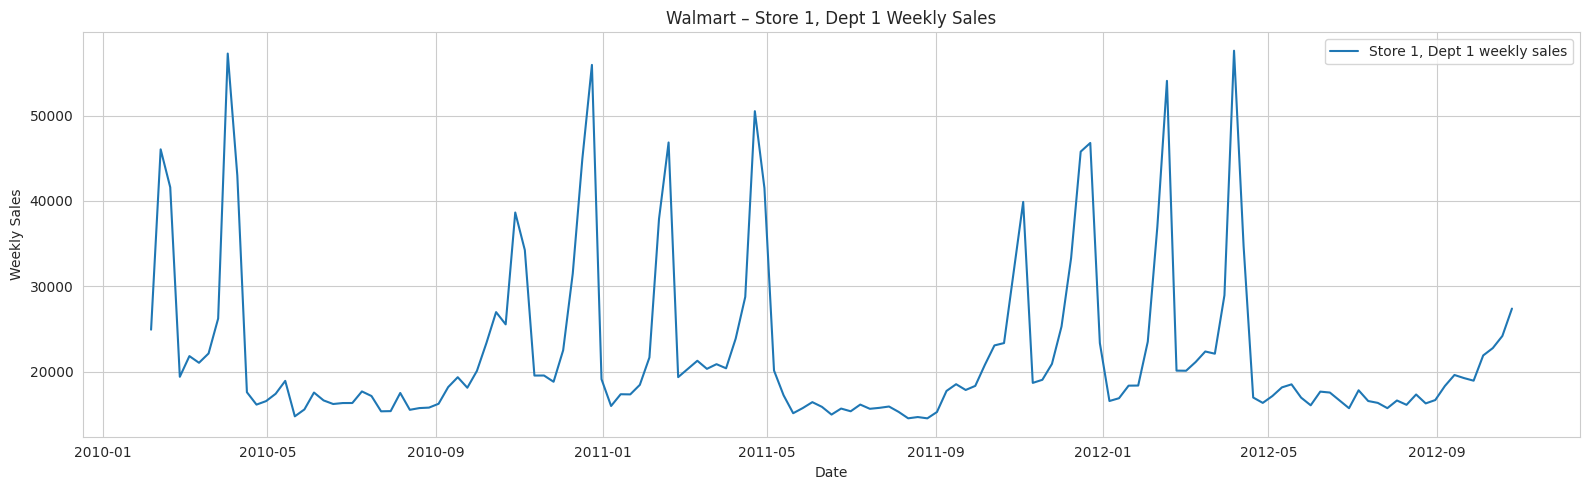

In [8]:
# Cell 8: Store-level Dept series (Store 1, Dept 1)

store_id = 1
dept_id = 1   # change if this dept doesn't exist or you want another one

s1d_ts = (
    train_merged[
        (train_merged["Store"] == store_id) &
        (train_merged["Dept"] == dept_id)
    ]
    .groupby("Date", as_index=True)["Weekly_Sales"]
    .sum()
    .sort_index()
)

print(f"Store {store_id}, Dept {dept_id} series length:", len(s1d_ts))
if len(s1d_ts) > 0:
    print("Date range:", s1d_ts.index.min(), "to", s1d_ts.index.max())
    print("\nFirst 5 rows:")
    print(s1d_ts.head())
else:
    print("Series is empty – choose a different dept_id.")

# Only plot if we have data
if len(s1d_ts) > 0:
    s1d_ts = s1d_ts.asfreq("W-FRI")

    plt.figure(figsize=(16, 5))
    plt.plot(s1d_ts.index, s1d_ts.values,
             label=f"Store {store_id}, Dept {dept_id} weekly sales", color="C0")
    plt.title(f"Walmart – Store {store_id}, Dept {dept_id} Weekly Sales")
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()

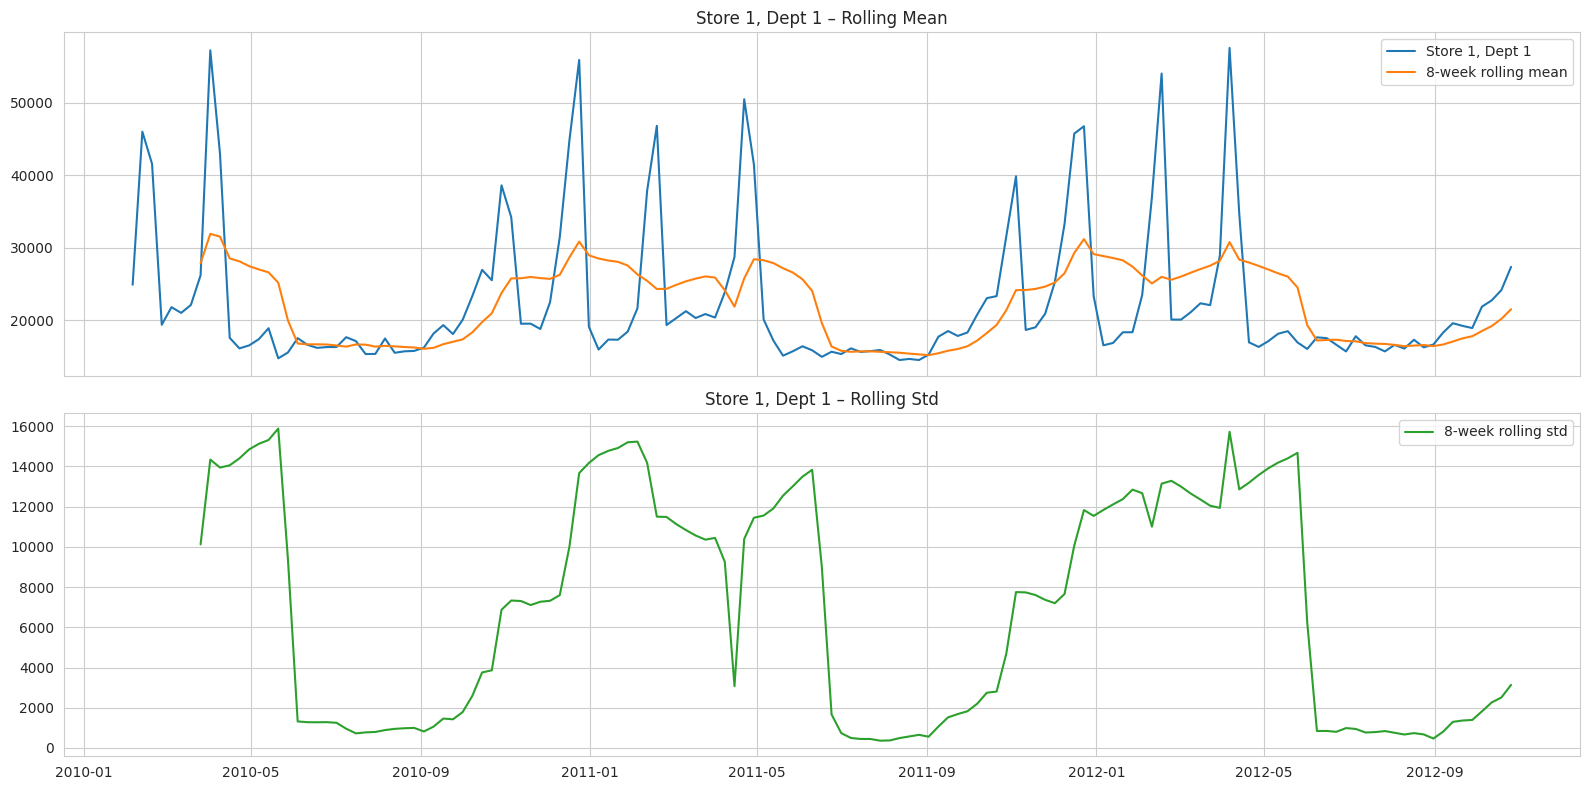

Store 1, Dept 1 – ADF on original
ADF statistic: -2.5222
p-value      :  0.1102
Critical values:
  1%: -3.4794
  5%: -2.8830
  10%: -2.5782

Store 1, Dept 1 – ADF on 1st difference
ADF statistic: -11.0443
p-value      :  0.0000
Critical values:
  1%: -3.4794
  5%: -2.8830
  10%: -2.5782


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



Store 1, Dept 1 – SARIMA(1,0,1)x(1,0,1,52) summary (coef table):
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1722      0.162      1.064      0.287      -0.145       0.489
ma.L1          0.6054      0.131      4.612      0.000       0.348       0.863
ar.S.L52       1.0821      0.243      4.444      0.000       0.605       1.559
ma.S.L52      -0.3181      0.280     -1.137      0.256      -0.867       0.230
sigma2       7.73e+07   3.55e-09   2.18e+16      0.000    7.73e+07    7.73e+07


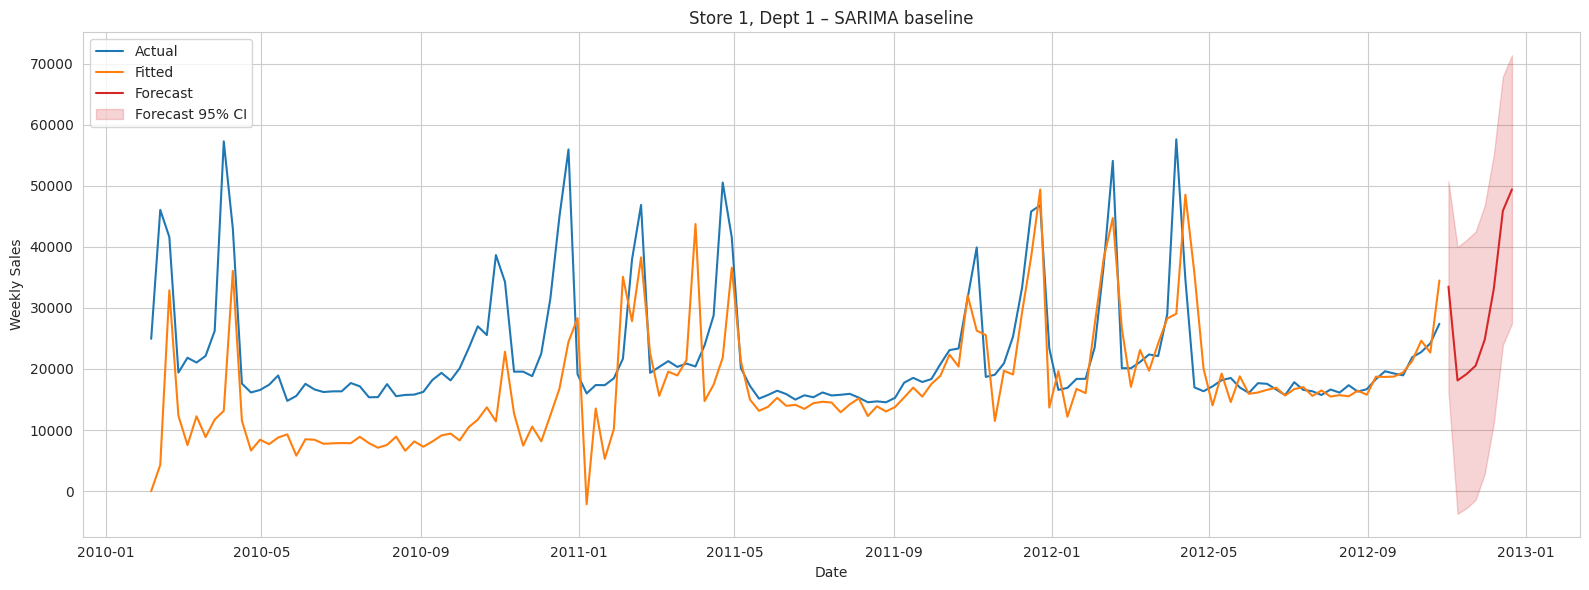

In [9]:
# Cell 9: Store 1, Dept 1 – rolling stats, ADF, SARIMA

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Weekly frequency
s1d_ts = s1d_ts.asfreq("W-FRI")

# Rolling mean & std
window = 8
s1d_roll_mean = s1d_ts.rolling(window=window).mean()
s1d_roll_std = s1d_ts.rolling(window=window).std()

fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax[0].plot(s1d_ts.index, s1d_ts.values, label="Store 1, Dept 1", color="C0")
ax[0].plot(s1d_roll_mean.index, s1d_roll_mean.values,
           label=f"{window}-week rolling mean", color="C1")
ax[0].set_title("Store 1, Dept 1 – Rolling Mean")
ax[0].legend()

ax[1].plot(s1d_roll_std.index, s1d_roll_std.values,
           label=f"{window}-week rolling std", color="C2")
ax[1].set_title("Store 1, Dept 1 – Rolling Std")
ax[1].legend()

plt.tight_layout()
plt.show()

# ADF tests
adf_s1d = adfuller(s1d_ts.dropna().values)
print("Store 1, Dept 1 – ADF on original")
print(f"ADF statistic: {adf_s1d[0]: .4f}")
print(f"p-value      : {adf_s1d[1]: .4f}")
print("Critical values:")
for k, v in adf_s1d[4].items():
    print(f"  {k}: {v:.4f}")

s1d_diff1 = s1d_ts.diff().dropna()
adf_s1d_diff = adfuller(s1d_diff1.values)
print("\nStore 1, Dept 1 – ADF on 1st difference")
print(f"ADF statistic: {adf_s1d_diff[0]: .4f}")
print(f"p-value      : {adf_s1d_diff[1]: .4f}")
print("Critical values:")
for k, v in adf_s1d_diff[4].items():
    print(f"  {k}: {v:.4f}")

# Simple SARIMA baseline on dept series
s1d_model = SARIMAX(
    s1d_ts,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
s1d_res = s1d_model.fit(disp=False)

print("\nStore 1, Dept 1 – SARIMA(1,0,1)x(1,0,1,52) summary (coef table):")
print(s1d_res.summary().tables[1])

# Fitted + 8-week forecast
n_forecast = 8
s1d_pred = s1d_res.get_prediction()
s1d_pred_mean = s1d_pred.predicted_mean

s1d_forecast = s1d_res.get_forecast(steps=n_forecast)
s1d_fc_idx = s1d_forecast.row_labels
s1d_fc_mean = s1d_forecast.predicted_mean
s1d_fc_ci = s1d_forecast.conf_int()

plt.figure(figsize=(16, 6))
plt.plot(s1d_ts.index, s1d_ts.values, label="Actual", color="C0")
plt.plot(s1d_pred_mean.index, s1d_pred_mean.values, label="Fitted", color="C1")
plt.plot(s1d_fc_idx, s1d_fc_mean, label="Forecast", color="C3")
plt.fill_between(
    s1d_fc_idx,
    s1d_fc_ci["lower Weekly_Sales"],
    s1d_fc_ci["upper Weekly_Sales"],
    color="C3",
    alpha=0.2,
    label="Forecast 95% CI",
)
plt.title("Store 1, Dept 1 – SARIMA baseline")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Cell 10: Feature engineering for ML models (panel data)

df = pd.concat(
    [
        train_merged.assign(dataset="train"),
        test.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
            .merge(stores, on="Store", how="left")
            .assign(dataset="test", Weekly_Sales=np.nan)
    ],
    ignore_index=True
)

print("Combined df shape:", df.shape)

# Date features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day
df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)

# Relative position of holidays (simple example)
# Distance in weeks to nearest holiday in dataset
holiday_dates = df.loc[df["IsHoliday"] == True, "Date"].drop_duplicates().sort_values()
def weeks_to_nearest_holiday(d):
    return ( (holiday_dates - d).abs().dt.days.min() // 7 )
df["WeeksToHoliday"] = df["Date"].apply(weeks_to_nearest_holiday)

# Handle markdown NAs as 0 (no markdown)
markdown_cols = [c for c in df.columns if c.startswith("MarkDown")]
df[markdown_cols] = df[markdown_cols].fillna(0.0)

# CPI and Unemployment: sort then forward-fill within Store
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)
for col in ["CPI", "Unemployment"]:
    if col in df.columns:
        df[col] = df.groupby("Store")[col].transform(lambda s: s.ffill().bfill())

# Basic sanity check
print("\nNA counts after preprocessing (top 15):")
print(
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

print("\nSample rows:")
print(df.head())

Combined df shape: (536634, 17)

NA counts after preprocessing (top 15):
Weekly_Sales    115064
Store                0
Dept                 0
Date                 0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1            0
MarkDown2            0
MarkDown3            0
MarkDown4            0
MarkDown5            0
CPI                  0
Unemployment         0
Type                 0
dtype: int64

Sample rows:
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50      False        42.31       2.572   
1      1     2 2010-02-05      50605.27      False        42.31       2.572   
2      1     3 2010-02-05      13740.12      False        42.31       2.572   
3      1     4 2010-02-05      39954.04      False        42.31       2.572   
4      1     5 2010-02-05      32229.38      False        42.31       2.572   

   MarkDown1  MarkDown2  MarkDown3  ...  Type    Size  dataset  Year Month  \
0 

In [11]:
# Cell 11: Split back into train/test and prepare for ML models

from sklearn.preprocessing import LabelEncoder

# Split by dataset flag
df_train = df[df["dataset"] == "train"].copy()
df_test  = df[df["dataset"] == "test"].copy()

print("df_train shape:", df_train.shape)
print("df_test shape :", df_test.shape)

# Drop helper column
df_train = df_train.drop(columns=["dataset"])
df_test  = df_test.drop(columns=["dataset"])

# Label encode categorical features
cat_cols = ["Store", "Dept", "Type"]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fit on combined values to keep mapping consistent
    le.fit(pd.concat([df_train[col], df_test[col]], axis=0))
    df_train[col] = le.transform(df_train[col])
    df_test[col]  = le.transform(df_test[col])
    encoders[col] = le

print("\nEncoded categorical columns:", cat_cols)

# Define feature list (all non-target, non-date columns)
feature_cols = [
    c for c in df_train.columns
    if c not in ["Weekly_Sales", "Date"]
]

print("\nNumber of features:", len(feature_cols))
print("Feature sample:", feature_cols[:10])

# Time-based split: use 2010-2011 as training, 2012 as validation
split_date = pd.Timestamp("2012-01-01")

train_mask = df_train["Date"] < split_date
valid_mask = df_train["Date"] >= split_date

X_train = df_train.loc[train_mask, feature_cols]
y_train = df_train.loc[train_mask, "Weekly_Sales"]

X_valid = df_train.loc[valid_mask, feature_cols]
y_valid = df_train.loc[valid_mask, "Weekly_Sales"]

print("\nTime-based split:")
print("Train period:", df_train.loc[train_mask, "Date"].min(), "to", df_train.loc[train_mask, "Date"].max())
print("Valid period:", df_train.loc[valid_mask, "Date"].min(), "to", df_train.loc[valid_mask, "Date"].max())
print("X_train:", X_train.shape, "X_valid:", X_valid.shape)

df_train shape: (421570, 24)
df_test shape : (115064, 24)

Encoded categorical columns: ['Store', 'Dept', 'Type']

Number of features: 21
Feature sample: ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

Time-based split:
Train period: 2010-02-05 00:00:00 to 2011-12-30 00:00:00
Valid period: 2012-01-06 00:00:00 to 2012-10-26 00:00:00
X_train: (294132, 21) X_valid: (127438, 21)


In [13]:
# Cell 12A: Faster baseline with progress bar-like verbose output

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# HistGradientBoosting is much faster than RandomForest on large tabular data
hgb = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=200,
    max_depth=8,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42,
    verbose=1
)

%time hgb.fit(X_train, y_train)

y_pred_valid = hgb.predict(X_valid)

mae = mean_absolute_error(y_valid, y_pred_valid)
mse = mean_squared_error(y_valid, y_pred_valid)
rmse = np.sqrt(mse)
r2 = r2_score(y_valid, y_pred_valid)

print(f"\nHistGBR – Validation MAE : {mae:,.2f}")
print(f"HistGBR – Validation RMSE: {rmse:,.2f}")
print(f"HistGBR – Validation R²  : {r2:.4f}")

Binning 0.044 GB of training data: 1.267 s
Binning 0.005 GB of validation data: 0.080 s
Fitting gradient boosted rounds:
Fit 200 trees in 18.593 s, (6200 total leaves)
Time spent computing histograms: 10.924s
Time spent finding best splits:  0.723s
Time spent applying splits:      2.901s
Time spent predicting:           0.362s
CPU times: user 12.1 s, sys: 163 ms, total: 12.3 s
Wall time: 18.6 s

HistGBR – Validation MAE : 4,233.69
HistGBR – Validation RMSE: 6,863.12
HistGBR – Validation R²  : 0.9037


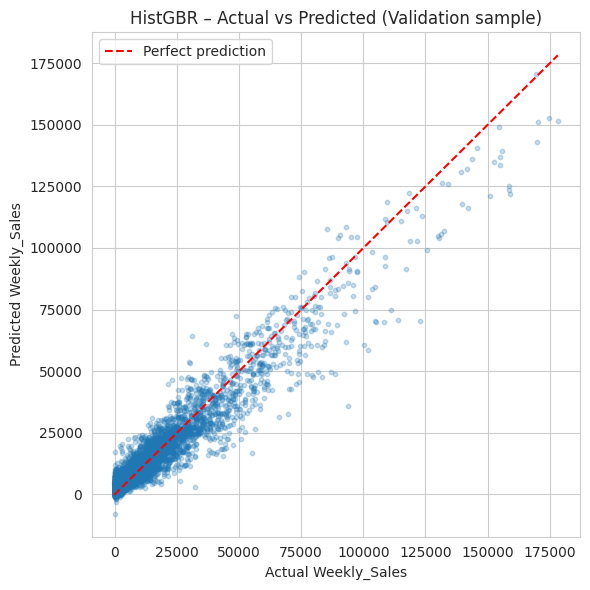

In [16]:
# Cell 12B: Actual vs predicted scatter (validation)

import numpy as np
import matplotlib.pyplot as plt

sample_size = min(5000, len(y_valid))
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(y_valid), size=sample_size, replace=False)

y_valid_sample = y_valid.iloc[sample_idx]
y_pred_sample = hgb.predict(X_valid.iloc[sample_idx])

plt.figure(figsize=(6, 6))
plt.scatter(y_valid_sample, y_pred_sample, alpha=0.25, s=10)
min_y = y_valid_sample.min()
max_y = y_valid_sample.max()
plt.plot([min_y, max_y], [min_y, max_y],
         color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Weekly_Sales")
plt.ylabel("Predicted Weekly_Sales")
plt.title("HistGBR – Actual vs Predicted (Validation sample)")
plt.legend()
plt.tight_layout()
plt.show()

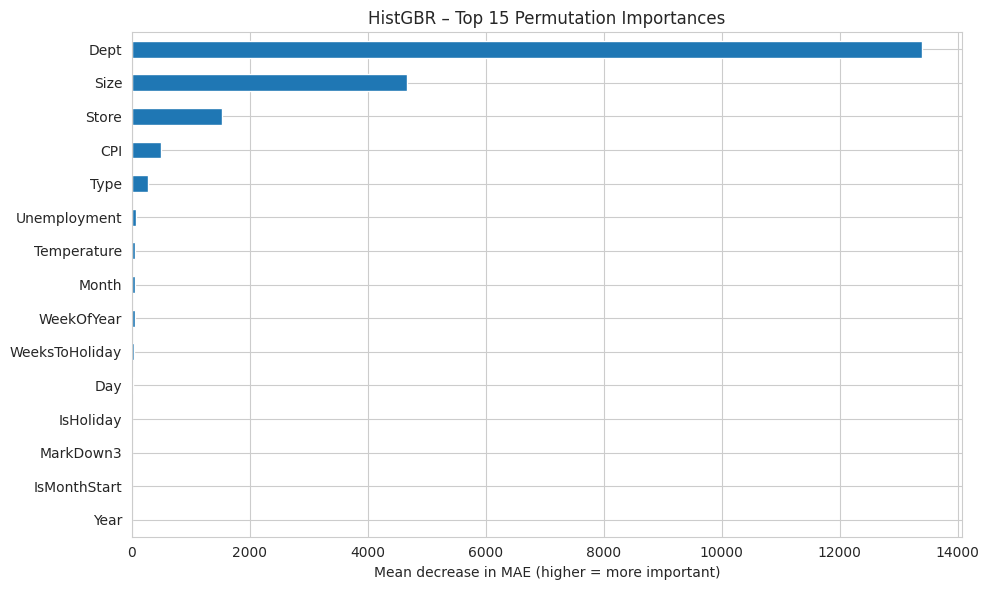


Top 15 features:
Dept              13393.401659
Size               4664.931027
Store              1532.191398
CPI                 492.643017
Type                266.807311
Unemployment         66.475621
Temperature          51.458089
Month                45.854178
WeekOfYear           44.697150
WeeksToHoliday       36.178646
Day                  19.010739
IsHoliday             1.947946
MarkDown3             0.962859
IsMonthStart          0.000000
Year                  0.000000
dtype: float64


In [17]:
# Cell 12C: Permutation importance for HistGBR

from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

sample_n = min(20000, len(X_valid))
rng = np.random.RandomState(42)
perm_idx = rng.choice(len(X_valid), size=sample_n, replace=False)

X_valid_sample = X_valid.iloc[perm_idx]
y_valid_sample = y_valid.iloc[perm_idx]

perm = permutation_importance(
    hgb,
    X_valid_sample,
    y_valid_sample,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
perm_importance.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("HistGBR – Top 15 Permutation Importances")
plt.xlabel("Mean decrease in MAE (higher = more important)")
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(perm_importance.head(15))

In [18]:
# Predict on test set with trained hgb (2010-2011 train, 2012 val se trained)
test_preds = hgb.predict(df_test[feature_cols])

submission = df_test[["Store", "Dept", "Date"]].copy()
submission["Weekly_Sales"] = test_preds

# Optional: Kaggle-style Id
submission["Id"] = (
    submission["Store"].astype(str) + "_" +
    submission["Dept"].astype(str) + "_" +
    submission["Date"].dt.strftime("%Y-%m-%d")
)

submission.to_csv("submission_histgbr.csv", index=False)
submission.head()

,Store,Dept,Date,Weekly_Sales,Id
10244,0,0,2012-11-02,21990.622355,0_0_2012-11-02
10245,0,1,2012-11-02,39433.117467,0_1_2012-11-02
10246,0,2,2012-11-02,10666.596432,0_2_2012-11-02
10247,0,3,2012-11-02,26258.236784,0_3_2012-11-02
10248,0,4,2012-11-02,19414.916996,0_4_2012-11-02


In [19]:
# Cell 13: Train final model on full training data

from sklearn.ensemble import HistGradientBoostingRegressor

X_full = df_train[feature_cols].copy()
y_full = df_train["Weekly_Sales"].copy()

print("X_full shape:", X_full.shape)
print("y_full shape:", y_full.shape)

final_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=200,
    max_depth=8,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42,
    verbose=1
)

%time final_model.fit(X_full, y_full)
print("Final model training complete.")

X_full shape: (421570, 21)
y_full shape: (421570,)
Binning 0.064 GB of training data: 1.138 s
Binning 0.007 GB of validation data: 0.097 s
Fitting gradient boosted rounds:
Fit 200 trees in 17.225 s, (6200 total leaves)
Time spent computing histograms: 10.309s
Time spent finding best splits:  0.504s
Time spent applying splits:      2.715s
Time spent predicting:           0.358s
CPU times: user 15.4 s, sys: 118 ms, total: 15.6 s
Wall time: 17.2 s
Final model training complete.


In [20]:
# Cell 14: Save model artifacts for reuse

import joblib
import os

os.makedirs("artifacts", exist_ok=True)

artifacts = {
    "model": final_model,
    "encoders": encoders,        # dict: { "Store": LabelEncoder, ... }
    "feature_cols": feature_cols
}

artifact_path = "artifacts/walmart_histgbr_artifacts.joblib"
joblib.dump(artifacts, artifact_path)

print("Saved artifacts to:", artifact_path)
print("Files in artifacts/:", os.listdir("artifacts"))

Saved artifacts to: artifacts/walmart_histgbr_artifacts.joblib
Files in artifacts/: ['walmart_histgbr_artifacts.joblib']


In [21]:
# Cell 15: Predict on test set and create submission.csv

# Use the same feature list as training
X_test = df_test[feature_cols].copy()
print("X_test shape:", X_test.shape)

test_preds = final_model.predict(X_test)

submission = df_test[["Store", "Dept", "Date"]].copy()
submission["Weekly_Sales"] = test_preds

# Optional Kaggle-style Id
submission["Id"] = (
    submission["Store"].astype(str) + "_" +
    submission["Dept"].astype(str) + "_" +
    submission["Date"].dt.strftime("%Y-%m-%d")
)

submission_path = "submission_histgbr.csv"
submission.to_csv(submission_path, index=False)

print("Saved submission file to:", submission_path)
print(submission.head())

X_test shape: (115064, 21)
Saved submission file to: submission_histgbr.csv
       Store  Dept       Date  Weekly_Sales              Id
10244      0     0 2012-11-02  21814.111036  0_0_2012-11-02
10245      0     1 2012-11-02  41746.846485  0_1_2012-11-02
10246      0     2 2012-11-02  13733.917610  0_2_2012-11-02
10247      0     3 2012-11-02  28506.915369  0_3_2012-11-02
10248      0     4 2012-11-02  22778.387485  0_4_2012-11-02


In [22]:
# Cell 16: Helper functions to load model and predict from raw merged data

import joblib
import pandas as pd
import numpy as np

ARTIFACT_PATH = "artifacts/walmart_histgbr_artifacts.joblib"

def load_artifacts(path=ARTIFACT_PATH):
    artifacts = joblib.load(path)
    return artifacts

def add_date_features(df):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["Day"] = df["Date"].dt.day
    df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
    df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)
    # WeeksToHoliday recompute:
    holiday_dates = df.loc[df["IsHoliday"] == True, "Date"].drop_duplicates().sort_values()
    if len(holiday_dates) > 0:
        def weeks_to_nearest(d):
            return int((holiday_dates - d).abs().dt.days.min() // 7)
        df["WeeksToHoliday"] = df["Date"].apply(weeks_to_nearest)
    else:
        df["WeeksToHoliday"] = 0
    return df

def predict_from_raw(raw_df, artifacts=None):
    """
    raw_df: DataFrame with at least columns:
      Store, Dept, Date, IsHoliday,
      Temperature, Fuel_Price, MarkDown1-5, CPI, Unemployment, Type, Size
      (same as train_merged schema)
    """
    if artifacts is None:
        artifacts = load_artifacts()

    model = artifacts["model"]
    encoders = artifacts["encoders"]
    feature_cols = artifacts["feature_cols"]

    df = raw_df.copy()
    df = add_date_features(df)

    # Handle markdown + CPI/Unemployment same as training
    markdown_cols = [c for c in df.columns if c.startswith("MarkDown")]
    if markdown_cols:
        df[markdown_cols] = df[markdown_cols].fillna(0.0)

    for col in ["CPI", "Unemployment"]:
        if col in df.columns:
            df[col] = df.groupby("Store")[col].transform(lambda s: s.ffill().bfill())

    # Label encode categorical columns
    for col, le in encoders.items():
        df[col] = le.transform(df[col])

    X = df[feature_cols]
    preds = model.predict(X)
    return preds

In [23]:
# Create merged test input for VS Code inference

input_test = (
    test.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
        .merge(stores, on="Store", how="left")
)

print("input_test shape:", input_test.shape)
print("\nColumns:")
print(input_test.columns.tolist())

input_test.to_csv("input_test.csv", index=False)
print("\nSaved: input_test.csv")

input_test shape: (115064, 15)

Columns:
['Store', 'Dept', 'Date', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']

Saved: input_test.csv
